# Leave-One-Subject-Out (LOSO) Cross-Validation

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)

PALETTE = {
    "PD":      "#E24B4A",
    "Healthy": "#378ADD",
    "SVM":     "#7F77DD",
    "HGB":     "#1D9E75",
    "LR":      "#BA7517",
    "RF":      "#B07FC8",
    "All":     "#D4537E",
    "JS":      "#639922",
}

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})
sns.set_style("whitegrid")

## Load Data

In [ ]:
train_a = pd.read_csv('../data/train_a.csv')
test_a  = pd.read_csv('../data/test_a.csv')
train_b = pd.read_csv('../data/train_b.csv')
test_b  = pd.read_csv('../data/test_b.csv')

full_a = pd.concat([train_a, test_a], ignore_index=True)
full_b = pd.concat([train_b, test_b], ignore_index=True)

feature_cols = [c for c in full_a.columns if c not in ('name', 'status')]
JITTER_SHIMMER = [
    'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
    'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
    'MDVP:APQ', 'Shimmer:DDA',
]

# Group by subject: 'phon_R01_S05_1' → 'phon_R01_S05'
for df in [full_a, full_b]:
    df['subject'] = df['name'].str.rsplit('_', n=1).str[0]

print(f'Dataset A: {len(full_a)} recordings, {full_a["subject"].nunique()} subjects')
print(f'Dataset B: {len(full_b)} recordings, {full_b["subject"].nunique()} subjects')
print(f'Status distribution A: {full_a["status"].value_counts().sort_index().to_dict()}  (0=Healthy, 1=PD)')

Dataset A: 195 recordings, 32 subjects
Dataset B: 187 recordings, 32 subjects
Status distribution A: {0.0: 48, 1.0: 147}  (0=Healthy, 1=PD)


In [ ]:
from sklearn.decomposition import PCA

def flag_outliers(df, feat_cols):
    """Flag outlier recordings using IQR (≥3 features), Z-score (|z|>3), and PCA/Mahalanobis (97.5th pct)."""
    # IQR
    def iqr_flag(series):
        Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
        IQR = Q3 - Q1
        return (series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)
    iqr_outlier = pd.DataFrame({f: iqr_flag(df[f]) for f in feat_cols}).sum(axis=1) >= 3

    # Z-score
    X_scaled       = StandardScaler().fit_transform(df[feat_cols])
    zscore_outlier = (np.abs(X_scaled) > 3).any(axis=1)

    # PCA + per-group Mahalanobis distance
    X_pca = PCA(n_components=2).fit_transform(X_scaled)
    def mahal_dist(X):
        mu      = X.mean(axis=0)
        inv_cov = np.linalg.pinv(np.cov(X.T))
        diff    = X - mu
        return np.sqrt(np.einsum('ij,jk,ik->i', diff, inv_cov, diff))
    mahal = np.zeros(len(df))
    for g in df['status'].unique():
        mask = (df['status'] == g).values
        mahal[mask] = mahal_dist(X_pca[mask])
    pca_outlier = mahal > np.percentile(mahal, 97.5)

    return pd.Series(iqr_outlier.values | zscore_outlier | pca_outlier, index=df.index)

full_a['any_outlier'] = flag_outliers(full_a, feature_cols)
full_b['any_outlier'] = flag_outliers(full_b, feature_cols)

clean_a = full_a[~full_a['any_outlier']].reset_index(drop=True)
clean_b = full_b[~full_b['any_outlier']].reset_index(drop=True)

print(f'Dataset A: {len(full_a)} recordings, {full_a["any_outlier"].sum()} outliers → {len(clean_a)} clean')
print(f'Dataset B: {len(full_b)} recordings, {full_b["any_outlier"].sum()} outliers → {len(clean_b)} clean')

Dataset A: 195 recordings, 23 outliers → 172 clean
Dataset B: 187 recordings, 22 outliers → 165 clean


LogTransformer

In [ ]:
SKEWED_FEATURES = ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'PPE', 'spread1', 'D2']


class LogTransformer(BaseEstimator, TransformerMixin):
    """Log-transform skewed features, fit on training fold only."""

    def __init__(self, skewed_cols, all_cols):
        self.skewed_cols = skewed_cols
        self.all_cols    = all_cols

    def fit(self, X, y=None):
        df = pd.DataFrame(X, columns=self.all_cols)
        self.mins_    = {c: df[c].min()             for c in self.skewed_cols}
        self.use_log_ = {c: bool((df[c] > 0).all()) for c in self.skewed_cols}
        return self

    def transform(self, X, y=None):
        df = pd.DataFrame(X, columns=self.all_cols).copy()
        for c in self.skewed_cols:
            if self.use_log_[c]:
                df[c] = np.log(df[c])
            else:
                df[c] = np.log1p(df[c] - self.mins_[c])
        return df.values

LOSO Evaluation Function

Outer loop: `LeaveOneGroupOut` (one subject per fold).  
Inner loop: `GroupKFold(k=5)` inside `GridSearchCV`, same protocol as the original model notebooks, now applied within each LOSO fold so no leakage occurs.

In [ ]:
def loso_evaluate(pipe, param_grid, X, y, groups,
                  inner_k=5, scoring='balanced_accuracy'):
    logo = LeaveOneGroupOut()
    ba_scores, f1_scores = [], []

    for train_idx, test_idx in logo.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        g_tr       = groups[train_idx]

        # Inner CV: also group-based to prevent leakage within the inner loop
        n_inner  = min(inner_k, len(np.unique(g_tr)))
        inner_cv = GroupKFold(n_splits=n_inner)

        gs = GridSearchCV(pipe, param_grid, cv=inner_cv,
                          scoring=scoring, n_jobs=-1, refit=True)
        gs.fit(X_tr, y_tr, groups=g_tr)

        y_pred = gs.predict(X_te)
        ba_scores.append(balanced_accuracy_score(y_te, y_pred))
        f1_scores.append(f1_score(y_te, y_pred, average='macro', zero_division=0))

    return np.array(ba_scores), np.array(f1_scores)

## Model Pipelines and Hyperparameter Grids

Exact same grids as the original model notebooks

In [ ]:
# SVM (from svm_classification.ipynb)
def make_svm(feat_cols):
    skewed = [c for c in SKEWED_FEATURES if c in feat_cols]
    pipe = Pipeline([
        ('log',    LogTransformer(skewed_cols=skewed, all_cols=feat_cols)),
        ('scaler', StandardScaler()),
        ('svm',    SVC(kernel='rbf', class_weight='balanced', random_state=42)),
    ])
    grid = {
        'svm__C':     [0.1, 1, 10, 100],
        'svm__gamma': ['scale', 'auto'],
    }
    return pipe, grid


# Logistic Regression (from Logistic regression.ipynb)
def make_lr(feat_cols):
    skewed = [c for c in SKEWED_FEATURES if c in feat_cols]
    pipe = Pipeline([
        ('log',    LogTransformer(skewed_cols=skewed, all_cols=feat_cols)),
        ('scaler', StandardScaler()),
        ('lr',     LogisticRegression(penalty='l1', solver='liblinear',
                                      class_weight='balanced', random_state=42,
                                      max_iter=1000)),
    ])
    grid = {'lr__C': np.logspace(-3, 3, 10)}
    return pipe, grid


# HGB (from HGB_pipeline.ipynb)
def make_hgb():
    # No LogTransformer — HGB handles mixed scales natively
    # early_stopping reduces effective max_iter and speeds up fitting
    pipe = Pipeline([
        ('hgb', HistGradientBoostingClassifier(
            class_weight='balanced', random_state=42,
            early_stopping=True, validation_fraction=0.15, n_iter_no_change=20,
        )),
    ])
    grid = {
        'hgb__learning_rate':    [0.03, 0.05, 0.08, 0.1],
        'hgb__max_iter':         [100, 200, 300],
        'hgb__max_leaf_nodes':   [5, 10, 15, 20, 31],
        'hgb__l2_regularization':[0.0, 0.01, 0.1, 1.0],
        'hgb__min_samples_leaf': [5, 10, 20],
    }
    return pipe, grid


# Random Forest (from random_forest_complete.ipynb)
def make_rf(feat_cols):
    skewed = [c for c in SKEWED_FEATURES if c in feat_cols]
    pipe = Pipeline([
        ('log',    LogTransformer(skewed_cols=skewed, all_cols=feat_cols)),
        ('scaler', StandardScaler()),
        ('rf',     RandomForestClassifier(class_weight='balanced', random_state=42)),
    ])
    grid = {
        'rf__n_estimators':     [100, 200],
        'rf__max_depth':        [None, 10, 20],
        'rf__min_samples_leaf': [1, 5],
    }
    return pipe, grid


print('Grid sizes (combos x 5 inner folds x 32 outer folds):')
import itertools
for name, g in [('SVM', {'C':[0.1,1,10,100],'gamma':['scale','auto']}),
                ('LR',  {'C': list(np.logspace(-3,3,10))}),
                ('HGB', {'lr':[0.03,0.05,0.08,0.1],'iter':[100,200,300],
                         'leaf':[5,10,15,20,31],'l2':[0.0,0.01,0.1,1.0],'ms':[5,10,20]}),
                ('RF',  {'n':[100,200],'d':[None,10,20],'ms':[1,5]})]:
    n = 1
    for v in g.values(): n *= len(v)
    print(f'  {name}: {n} combos x 5 x 32 = {n*5*32} total fits')

Grid sizes (combos x 5 inner folds x 32 outer folds):
  SVM: 8 combos x 5 x 32 = 1280 total fits
  LR: 10 combos x 5 x 32 = 1600 total fits
  HGB: 720 combos x 5 x 32 = 115200 total fits
  RF: 12 combos x 5 x 32 = 1920 total fits


## LOSO

Evaluates all 4 models on Dataset A and B, both feature sets.  

In [ ]:
import os, time

OUT_CSV = 'outputs/loso_results.csv'

def _csv_has_outliers():
    if not os.path.exists(OUT_CSV):
        return False
    return 'Outliers' in pd.read_csv(OUT_CSV, nrows=0).columns

if _csv_has_outliers():
    print(f'Found {OUT_CSV} with outlier data — loading. Delete file to re-run.')
    df_loso = pd.read_csv(OUT_CSV)
    display(df_loso)
else:
    loso_rows = []

    if os.path.exists(OUT_CSV):
        # Existing results are all "With Outliers" — reuse them, only run Without
        df_existing = pd.read_csv(OUT_CSV)
        df_existing['Outliers'] = 'With'
        loso_rows = df_existing.to_dict('records')
        print(f'Reusing {len(loso_rows)} existing rows as "With Outliers".')
        print('Running "Without Outliers" conditions only (~35 min).\n')
        run_conditions = [('Without', {'A': clean_a, 'B': clean_b})]
    else:
        print('No existing CSV — running all conditions (~70 min).\n')
        run_conditions = [
            ('With',    {'A': full_a,  'B': full_b}),
            ('Without', {'A': clean_a, 'B': clean_b}),
        ]

    feat_configs = {
        'All features':   feature_cols,
        'Jitter+Shimmer': JITTER_SHIMMER,
    }
    t0 = time.time()

    for outlier_label, datasets in run_conditions:
        for ds_key, df_full in datasets.items():
            y      = df_full['status'].values.astype(int)
            groups = df_full['subject'].values

            for feat_label, fc in feat_configs.items():
                X = df_full[fc].values

                for model_label, make_fn in [
                    ('SVM', lambda: make_svm(fc)),
                    ('LR',  lambda: make_lr(fc)),
                    ('RF',  lambda: make_rf(fc)),
                    ('HGB', lambda: make_hgb()),
                ]:
                    print(f'[{model_label}] Dataset {ds_key} | {outlier_label} outliers | {feat_label} ...', flush=True)
                    t1 = time.time()
                    pipe, grid = make_fn()
                    ba, f1 = loso_evaluate(pipe, grid, X, y, groups)
                    elapsed = time.time() - t1
                    print(f'  → BA = {ba.mean():.3f} ± {ba.std():.3f}  '
                          f'F1 = {f1.mean():.3f} ± {f1.std():.3f}  [{elapsed/60:.1f} min]')
                    loso_rows.append({
                        'Model':    model_label,
                        'Dataset':  ds_key,
                        'Features': feat_label,
                        'Outliers': outlier_label,
                        'BA_mean':  round(ba.mean(), 3),
                        'BA_std':   round(ba.std(),  3),
                        'F1_mean':  round(f1.mean(), 3),
                        'F1_std':   round(f1.std(),  3),
                        'n_folds':  len(ba),
                    })

    df_loso = pd.DataFrame(loso_rows)
    df_loso.to_csv(OUT_CSV, index=False)
    print(f'\nTotal runtime: {(time.time()-t0)/60:.1f} min')
    print(f'Saved: {OUT_CSV}')
    display(df_loso)

No existing CSV — running all conditions (~70 min).

[SVM] Dataset A | With outliers | All features ...
  → BA = 0.740 ± 0.358  F1 = 0.639 ± 0.386  [0.2 min]
[LR] Dataset A | With outliers | All features ...
  → BA = 0.711 ± 0.349  F1 = 0.585 ± 0.369  [0.3 min]
[RF] Dataset A | With outliers | All features ...
  → BA = 0.751 ± 0.380  F1 = 0.669 ± 0.401  [2.1 min]
[HGB] Dataset A | With outliers | All features ...


## Results Table

In [ ]:
df_loso = pd.read_csv('outputs/loso_results.csv')

df_loso['BA'] = df_loso.apply(lambda r: f"{r.BA_mean:.3f} ± {r.BA_std:.3f}", axis=1)
df_loso['F1'] = df_loso.apply(lambda r: f"{r.F1_mean:.3f} ± {r.F1_std:.3f}", axis=1)

idx_cols = ['Model', 'Dataset', 'Outliers'] if 'Outliers' in df_loso.columns else ['Model', 'Dataset']
pivot = df_loso.pivot_table(
    index=idx_cols,
    columns='Features',
    values=['BA', 'F1'],
    aggfunc='first'
)
display(pivot)

BA                            F1  \
Features                 All features Jitter+Shimmer   All features   
Model Dataset Outliers                                                
HGB   A       With      0.730 ± 0.358  0.653 ± 0.359  0.637 ± 0.385   
              Without   0.705 ± 0.383  0.698 ± 0.351  0.639 ± 0.405   
      B       With      0.746 ± 0.354  0.584 ± 0.397  0.676 ± 0.385   
              Without   0.711 ± 0.371  0.673 ± 0.340  0.610 ± 0.389   
LR    A       With      0.700 ± 0.360  0.666 ± 0.385  0.579 ± 0.375   
              Without   0.604 ± 0.388  0.633 ± 0.401  0.481 ± 0.374   
      B       With      0.673 ± 0.381  0.648 ± 0.385  0.564 ± 0.388   
              Without   0.683 ± 0.375  0.598 ± 0.407  0.600 ± 0.394   
RF    A       With      0.771 ± 0.381  0.714 ± 0.376  0.707 ± 0.402   
              Without   0.750 ± 0.379  0.692 ± 0.357  0.688 ± 0.402   
      B       With      0.755 ± 0.386  0.685 ± 0.380  0.701 ± 0.406   
              Without   0.757 ± 0.389  0.716 ± 0.378  0.688 ± 0.407   
SVM   A       With      0.714 ± 0.382  0.624 ± 0.409  0.625 ± 0.401   
              Without   0.667 ± 0.384  0.598 ± 0.416  0.574 ± 0.398   
      B       With      0.712 ± 0.356  0.641 ± 0.388  0.583 ± 0.374   
              Without   0.683 ± 0.372  0.726 ± 0.335  0.567 ± 0.382   

                                       
Features               Jitter+Shimmer  
Model Dataset Outliers                 
HGB   A       With      0.562 ± 0.384  
              Without   0.593 ± 0.379  
      B       With      0.509 ± 0.403  
              Without   0.554 ± 0.362  
LR    A       With      0.610 ± 0.404  
              Without   0.575 ± 0.415  
      B       With      0.554 ± 0.392  
              Without   0.542 ± 0.417  
RF    A       With      0.627 ± 0.396  
              Without   0.590 ± 0.381  
      B       With      0.600 ± 0.399  
              Without   0.644 ± 0.402  
SVM   A       With      0.554 ± 0.416  
              Without   0.538 ± 0.425  
      B       With      0.550 ± 0.396  
              Without   0.624 ± 0.371

## Visualisation

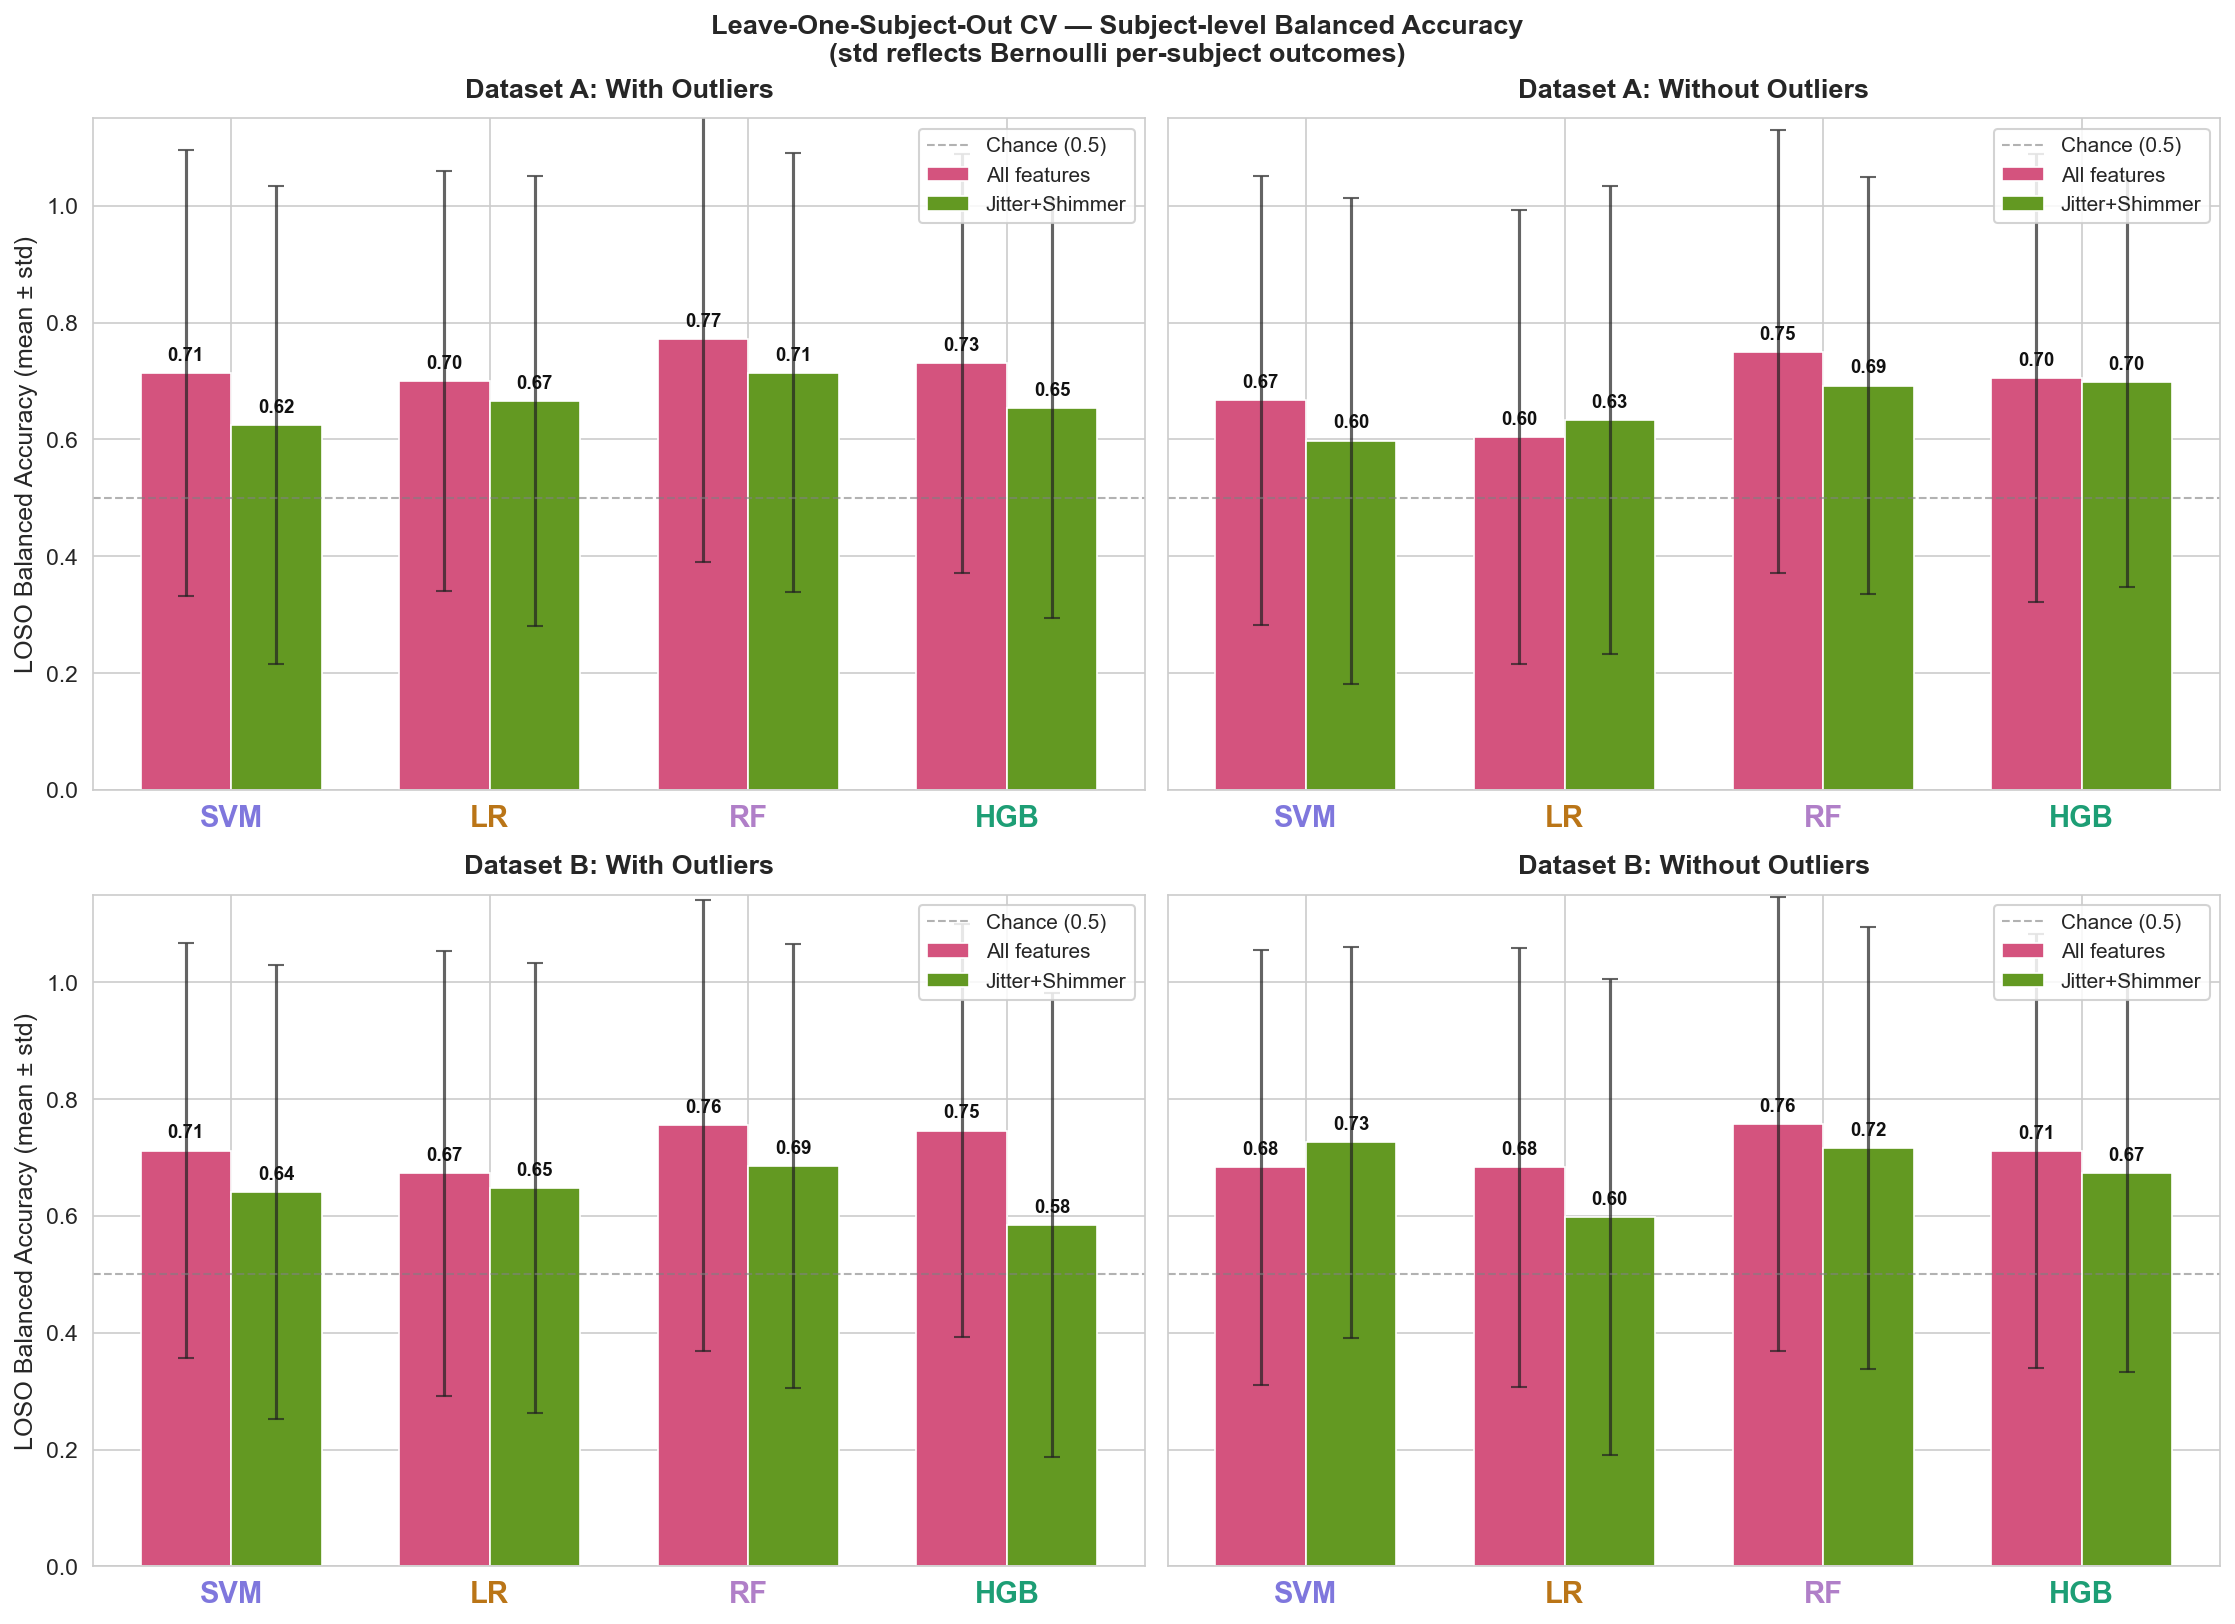

Saved: outputs/loso_results.png


In [ ]:
df_loso = pd.read_csv('outputs/loso_results.csv')

model_order  = ['SVM', 'LR', 'RF', 'HGB']
feat_order   = ['All features', 'Jitter+Shimmer']
feat_color   = {'All features': '#D4537E', 'Jitter+Shimmer': '#639922'}
feat_label_s = {'All features': 'All features', 'Jitter+Shimmer': 'Jitter+Shimmer'}

has_outliers = 'Outliers' in df_loso.columns

if has_outliers:
    fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharey=True)
    panels = [
        (axes[0, 0], 'A', 'With'),
        (axes[0, 1], 'A', 'Without'),
        (axes[1, 0], 'B', 'With'),
        (axes[1, 1], 'B', 'Without'),
    ]
else:
    fig, axes_1d = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
    panels = [(axes_1d[0], 'A', None), (axes_1d[1], 'B', None)]

x     = np.arange(len(model_order))
width = 0.35

for ax, ds_key, outlier_label in panels:
    df_ds = df_loso[df_loso['Dataset'] == ds_key]
    if has_outliers and outlier_label is not None:
        df_ds = df_ds[df_ds['Outliers'] == outlier_label]

    for i, feat in enumerate(feat_order):
        df_f   = df_ds[df_ds['Features'] == feat].set_index('Model')
        means  = [df_f.loc[m, 'BA_mean'] if m in df_f.index else 0 for m in model_order]
        stds   = [df_f.loc[m, 'BA_std']  if m in df_f.index else 0 for m in model_order]
        offset = (i - 0.5) * width

        bars = ax.bar(x + offset, means, width,
                      yerr=stds, capsize=4,
                      error_kw=dict(elinewidth=1.5, ecolor='#222222', alpha=0.7),
                      color=feat_color[feat],
                      edgecolor='white', linewidth=0.8,
                      label=feat_label_s[feat])
        for bar, mean in zip(bars, means):
            if mean > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.015,
                        f'{mean:.2f}', ha='center', va='bottom', fontsize=9,
                        fontweight='bold', color='#111111')

    ax.axhline(0.5, color='grey', linestyle='--', lw=1.0, alpha=0.6, label='Chance (0.5)')
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, fontsize=14, fontweight='bold')
    for tick, model in zip(ax.get_xticklabels(), model_order):
        tick.set_color(PALETTE[model])
    ax.set_ylim(0, 1.15)
    ax.tick_params(axis='y', labelsize=11)
    title = f'Dataset {ds_key}'
    if has_outliers and outlier_label:
        title += f': {outlier_label} Outliers'
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.legend(fontsize=10, loc='upper right', framealpha=0.85)

if has_outliers:
    axes[0, 0].set_ylabel('LOSO Balanced Accuracy (mean ± std)', fontsize=12)
    axes[1, 0].set_ylabel('LOSO Balanced Accuracy (mean ± std)', fontsize=12)
else:
    axes_1d[0].set_ylabel('LOSO Balanced Accuracy (mean ± std)', fontsize=12)

fig.suptitle(
    'Leave-One-Subject-Out CV — Subject-level Balanced Accuracy\n'
    '(std reflects Bernoulli per-subject outcomes)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('outputs/loso_results.png', dpi=200, bbox_inches='tight')
plt.savefig('outputs/loso_results_w-wooutliers.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: outputs/loso_results.png')

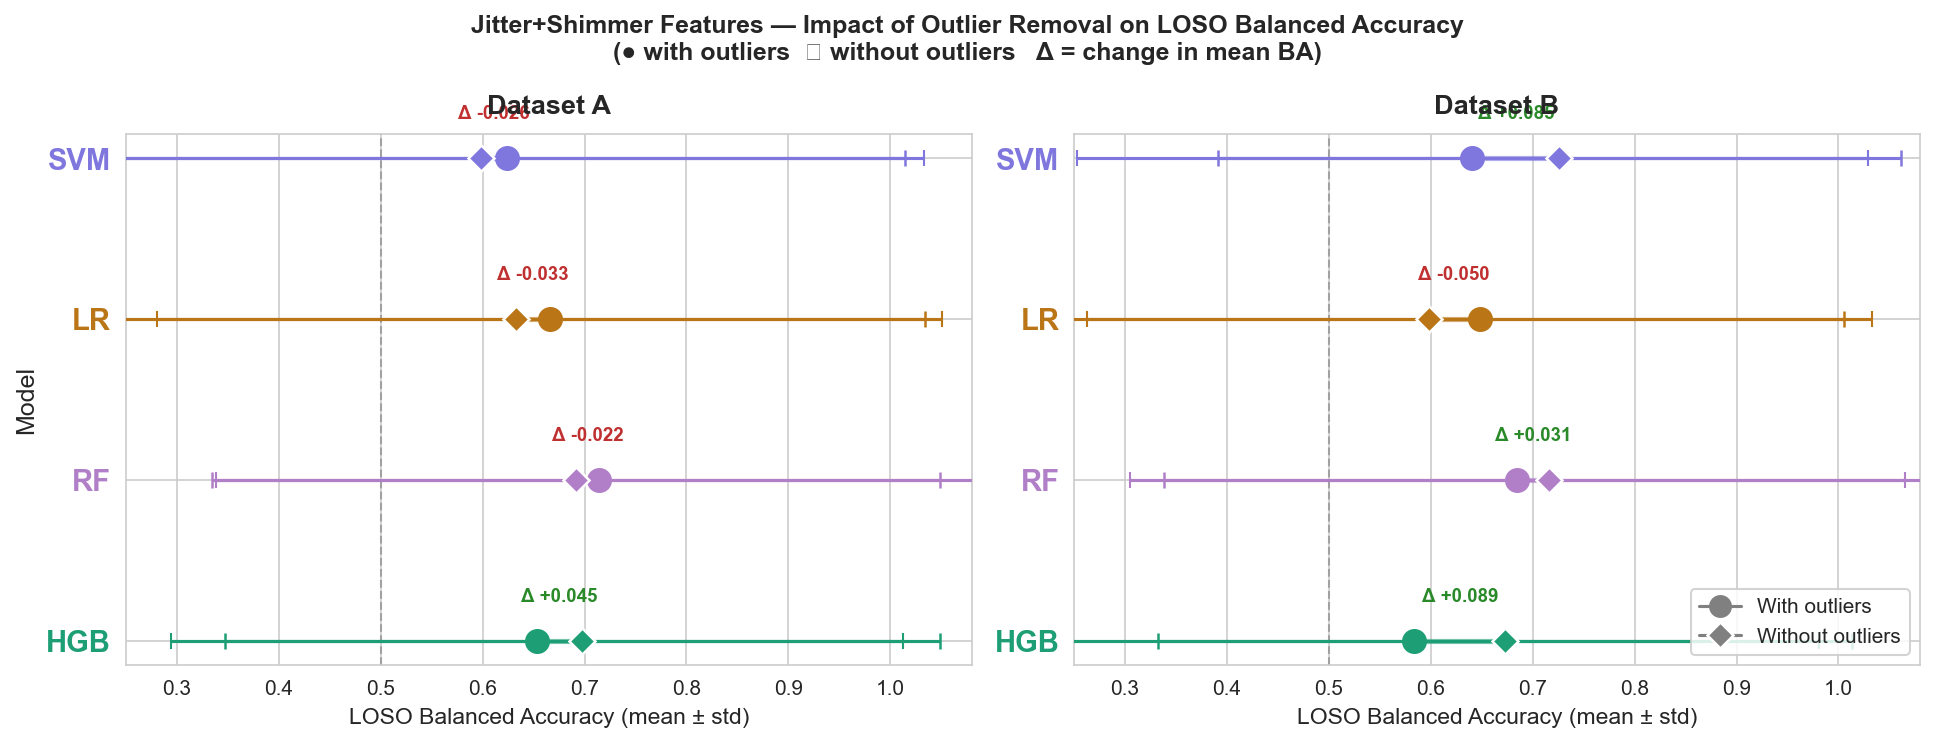

Saved: outputs/loso_outlier_impact_js.png


In [ ]:
from matplotlib.lines import Line2D

df_loso = pd.read_csv('outputs/loso_results.csv')

if 'Outliers' not in df_loso.columns:
    print("No outlier comparison data available.")
else:
    df_js = df_loso[df_loso['Features'] == 'Jitter+Shimmer']
    model_order = ['HGB', 'RF', 'LR', 'SVM']   # bottom→top so SVM is at top

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, ds_key in zip(axes, ['A', 'B']):
        df_ds = df_js[df_js['Dataset'] == ds_key]
        y_pos = np.arange(len(model_order))

        for yi, model in enumerate(model_order):
            df_m  = df_ds[df_ds['Model'] == model]
            row_w  = df_m[df_m['Outliers'] == 'With']
            row_wo = df_m[df_m['Outliers'] == 'Without']
            if row_w.empty or row_wo.empty:
                continue

            ba_w,  std_w  = row_w['BA_mean'].values[0],  row_w['BA_std'].values[0]
            ba_wo, std_wo = row_wo['BA_mean'].values[0], row_wo['BA_std'].values[0]
            color = PALETTE[model]
            delta = ba_wo - ba_w

            # connecting line
            ax.plot([ba_w, ba_wo], [yi, yi], color=color, lw=2.5, alpha=0.55, zorder=1)

            # with outliers → circle
            ax.errorbar(ba_w,  yi, xerr=std_w,  fmt='o', color=color,
                        markersize=11, capsize=4, elinewidth=1.5, zorder=3)
            # without outliers → diamond
            ax.errorbar(ba_wo, yi, xerr=std_wo, fmt='D', color=color,
                        markersize=9,  capsize=4, elinewidth=1.5, zorder=3,
                        markeredgecolor='white', markeredgewidth=1.2)

            # Δ annotation above the midpoint of the line
            sign  = '+' if delta >= 0 else ''
            dcol  = '#2a8a2a' if delta > 0.005 else ('#c03030' if delta < -0.005 else '#888888')
            ax.text((ba_w + ba_wo) / 2, yi + 0.22,
                    f'Δ {sign}{delta:.3f}',
                    ha='center', va='bottom', fontsize=9,
                    color=dcol, fontweight='bold')

        ax.axvline(0.5, color='grey', linestyle='--', lw=1.0, alpha=0.6)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(model_order, fontsize=14, fontweight='bold')
        for tick, model in zip(ax.get_yticklabels(), model_order):
            tick.set_color(PALETTE[model])
        ax.set_xlim(0.25, 1.08)
        ax.tick_params(axis='x', labelsize=10)
        ax.set_xlabel('LOSO Balanced Accuracy (mean ± std)', fontsize=11)
        ax.set_title(f'Dataset {ds_key}', fontsize=13, fontweight='bold', pad=10)

    legend_elements = [
        Line2D([0], [0], marker='o', color='grey', lw=1.5, markersize=10, label='With outliers'),
        Line2D([0], [0], marker='D', color='grey', lw=1.5, markersize=9,
               markeredgecolor='white', markeredgewidth=1.2, label='Without outliers'),
    ]
    axes[1].legend(handles=legend_elements, fontsize=10, loc='lower right', framealpha=0.85)
    axes[0].set_ylabel('Model', fontsize=12)

    fig.suptitle(
        'Jitter+Shimmer Features — Impact of Outlier Removal on LOSO Balanced Accuracy\n'
        '(● with outliers  ◆ without outliers   Δ = change in mean BA)',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('outputs/loso_outlier_impact_js.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved: outputs/loso_outlier_impact_js.png')

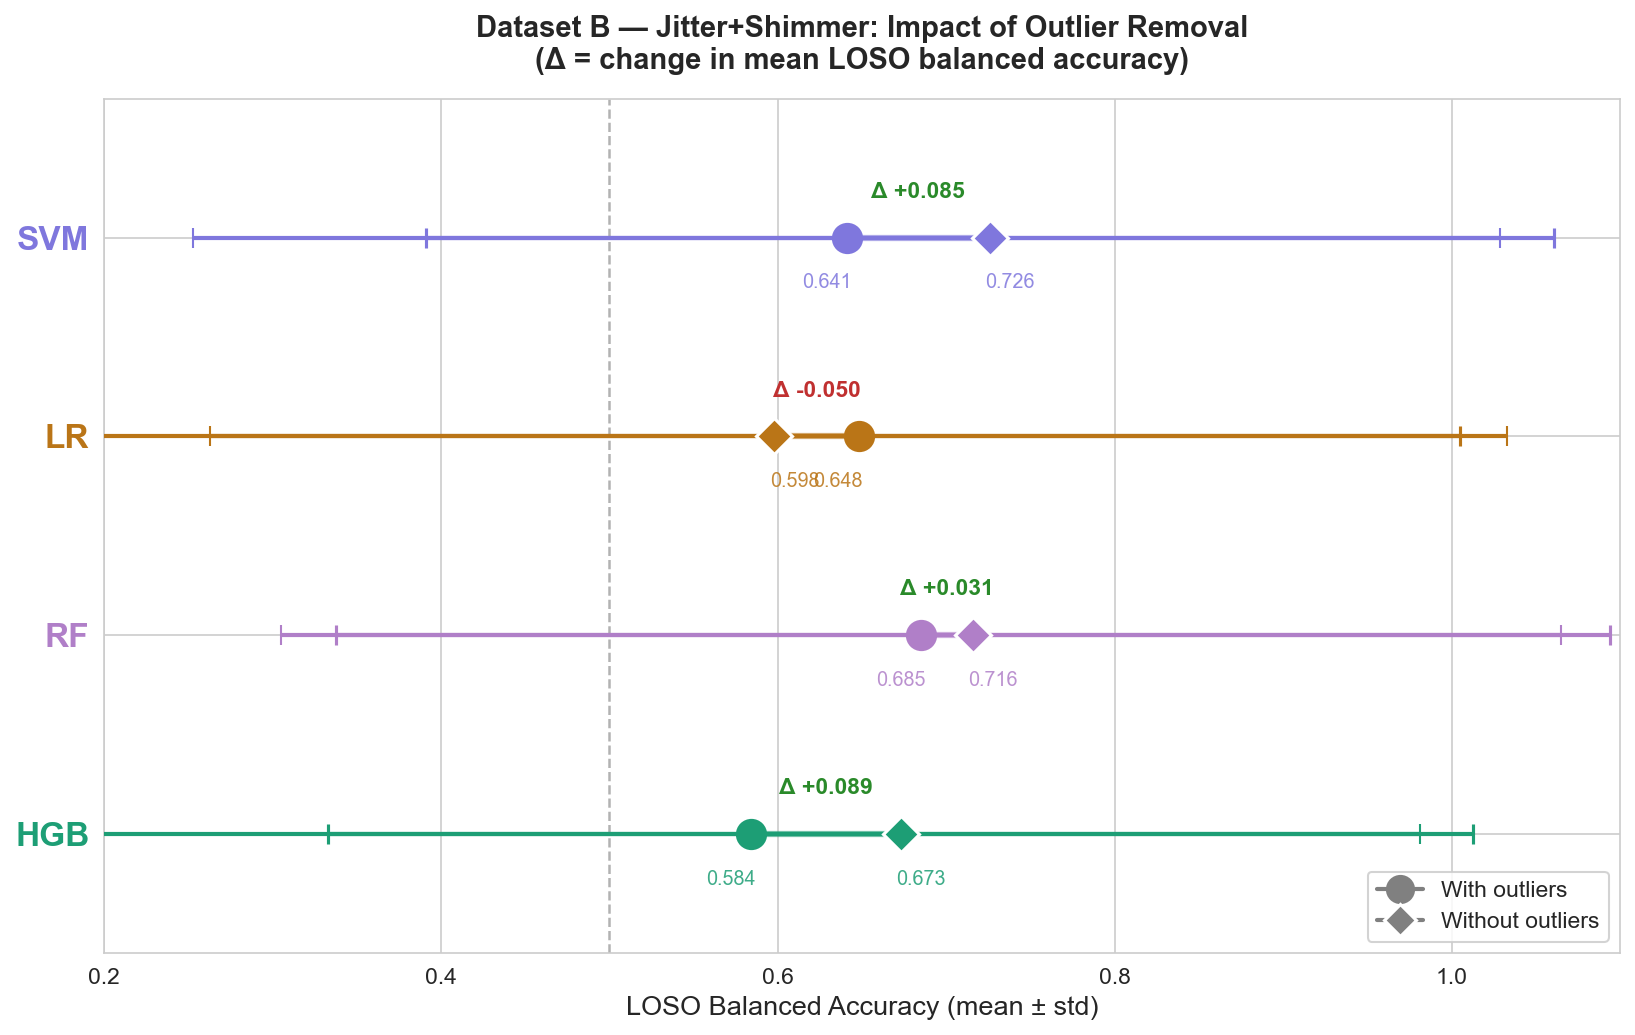

Saved: outputs/loso_outlier_impact_js_B.png


In [ ]:
from matplotlib.lines import Line2D

df_loso = pd.read_csv('outputs/loso_results.csv')

if 'Outliers' not in df_loso.columns:
    print("No outlier comparison data available.")
else:
    df_js = df_loso[(df_loso['Features'] == 'Jitter+Shimmer') & (df_loso['Dataset'] == 'B')]
    model_order = ['HGB', 'RF', 'LR', 'SVM']

    fig, ax = plt.subplots(figsize=(11, 7))
    y_pos = np.arange(len(model_order))

    for yi, model in enumerate(model_order):
        df_m   = df_js[df_js['Model'] == model]
        row_w  = df_m[df_m['Outliers'] == 'With']
        row_wo = df_m[df_m['Outliers'] == 'Without']
        if row_w.empty or row_wo.empty:
            continue

        ba_w,  std_w  = row_w['BA_mean'].values[0],  row_w['BA_std'].values[0]
        ba_wo, std_wo = row_wo['BA_mean'].values[0], row_wo['BA_std'].values[0]
        color = PALETTE[model]
        delta = ba_wo - ba_w

        # connecting line
        ax.plot([ba_w, ba_wo], [yi, yi], color=color, lw=3, alpha=0.55, zorder=1)

        # with outliers → circle
        ax.errorbar(ba_w,  yi, xerr=std_w,  fmt='o', color=color,
                    markersize=14, capsize=5, elinewidth=2, zorder=3)
        # without outliers → diamond
        ax.errorbar(ba_wo, yi, xerr=std_wo, fmt='D', color=color,
                    markersize=12, capsize=5, elinewidth=2, zorder=3,
                    markeredgecolor='white', markeredgewidth=1.5)

        # Δ annotation above midpoint
        sign = '+' if delta >= 0 else ''
        dcol = '#2a8a2a' if delta > 0.005 else ('#c03030' if delta < -0.005 else '#888888')
        ax.text((ba_w + ba_wo) / 2, yi + 0.18,
                f'Δ {sign}{delta:.3f}',
                ha='center', va='bottom', fontsize=11,
                color=dcol, fontweight='bold')

        # value labels next to each point
        ax.text(ba_w  - 0.012, yi - 0.18, f'{ba_w:.3f}',
                ha='center', va='top', fontsize=9.5, color=color, alpha=0.85)
        ax.text(ba_wo + 0.012, yi - 0.18, f'{ba_wo:.3f}',
                ha='center', va='top', fontsize=9.5, color=color, alpha=0.85)

    ax.axvline(0.5, color='grey', linestyle='--', lw=1.2, alpha=0.6, label='Chance (0.5)')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(model_order, fontsize=16, fontweight='bold')
    for tick, model in zip(ax.get_yticklabels(), model_order):
        tick.set_color(PALETTE[model])
    ax.set_xlim(0.2, 1.1)
    ax.set_ylim(-0.6, len(model_order) - 0.3)
    ax.tick_params(axis='x', labelsize=11)
    ax.set_xlabel('LOSO Balanced Accuracy (mean ± std)', fontsize=13)

    legend_elements = [
        Line2D([0], [0], marker='o', color='grey', lw=2, markersize=13, label='With outliers'),
        Line2D([0], [0], marker='D', color='grey', lw=2, markersize=11,
               markeredgecolor='white', markeredgewidth=1.5, label='Without outliers'),
    ]
    ax.legend(handles=legend_elements, fontsize=11, loc='lower right', framealpha=0.85)

    ax.set_title(
        'Dataset B — Jitter+Shimmer: Impact of Outlier Removal\n'
        '(Δ = change in mean LOSO balanced accuracy)',
        fontsize=14, fontweight='bold', pad=14
    )
    plt.tight_layout()
    plt.savefig('outputs/loso_outlier_impact_js_B.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved: outputs/loso_outlier_impact_js_B.png')